## TP1 - Michel Jean Joseph Donnet

In [121]:
## Imports
import numpy as np
import random
import matplotlib.pyplot as plt

In [122]:
# local fitness functions f_K for K = 0, 1, 2 (Table in TP)
f = {
    0: {
        '0': 2,
        '1': 1
    },
    1: { 
        '00': 2,
        '01': 3,
        '10': 2,
        '11': 0
    },
    2: {
        '000': 0,
        '001': 1,
        '010': 1,
        '011': 0,
        '100': 2,
        '101': 0,
        '110': 0,
        '111': 0
    }
}

In [126]:
def generate_sequence(N):
    # TODO
    '''
    generates an N random bits (0, 1) sequence

    Parameters:
    -----------
    N : number of bits in the sequence

    Returns:
    --------
    sequence: sequence of N bits
    '''
    sequence = ''
    for i in range(N):
        sequence += str(random.randint(0, 1))
    return sequence


def compute_fitness(sequence, K):
    # TODO
    '''
    computes the fitness of sequence, with respect to K, according to table f

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    fitness: fitness value of sequence
    '''
    fitness = 0
    for i in range(len(sequence) - K):
        fitness += f[K][sequence[i: i + K + 1]]
    return fitness

assert compute_fitness('0101', 0) == 6
assert compute_fitness('0101', 1) == 8
assert compute_fitness('0101', 2) == 1


def neighbors(sequence):
    ''' 
    returns all neighbors of sequence ()

    Parameters:
    -----------
    sequence : N-bits sequence

    Returns:
    --------
    generator of neighbors of sequence
    '''
    # generate all neighbors that differ in 1 bit 
    for i in range(len(sequence)):
        if sequence[i] == '0':
            new = '1'
        else: new = '0'
        yield (sequence[:i] + new + sequence[i + 1:])


def mean_steps(samples):
    ''' 
    returns mean of steps taken to find solution (for deterministic)

    Parameters:
    -----------
    samples : samples of deterministic_hillclimb runs

    Returns:
    --------
    mean steps
    '''
    # get mean of steps needed to find solution (sum of samples' steps/number of samples)
    return sum(x[2] for x in samples)/len(samples)


def generate_samples(hillclimb_method, K):
    ''' 
    generates 50 samples (solutions) for the hillclimb method (deterministic/probabilistic)

    Parameters:
    -----------
    hillclimb_method : deterministic_hillclimb/probabilistic_hillclimb
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    generator of samples/solutions (sequence, fitness, number of steps)
    '''
    if K not in [0, 1, 2]:
        raise Exception("Invalid K")

    # run for 50 times to get 50 samples/solutions
    for i in range(50):
        # generate initial sequence
        initial_sequence = generate_sequence(N=21)
        # get solution, its fitness, number of steps taken to find solution
        x, f_x, s = hillclimb_method(initial_sequence, K)
        yield (x, f_x, s)

In [127]:
[deterministic_hillclimb(generate_sequence(21),0) for _ in range(20)]

[('000000000000000000000', 42, 14),
 ('000000000000000000000', 42, 12),
 ('000000000000000000000', 42, 14),
 ('000000000000000000000', 42, 13),
 ('000000000000000000000', 42, 14),
 ('000000000000000000000', 42, 14),
 ('000000000000000000000', 42, 9),
 ('000000000000000000000', 42, 9),
 ('000000000000000000000', 42, 11),
 ('000000000000000000000', 42, 8),
 ('000000000000000000000', 42, 15),
 ('000000000000000000000', 42, 9),
 ('000000000000000000000', 42, 14),
 ('000000000000000000000', 42, 11),
 ('000000000000000000000', 42, 10),
 ('000000000000000000000', 42, 12),
 ('000000000000000000000', 42, 9),
 ('000000000000000000000', 42, 9),
 ('000000000000000000000', 42, 13),
 ('000000000000000000000', 42, 8)]

In [128]:
def deterministic_hillclimb(sequence, K):
    # TODO
    ''' 
    performs deterministic_hillclimb

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    sequence : optimal/fittest sequence found
    max_fitness : fitness value of sequence
    steps: steps it took to reach optimum 
    '''
    steps = 0
    current = sequence
    current_fitness = compute_fitness(sequence, K)
    cont = True
    while cont:
        steps += 1
        list_neighbors = list(neighbors(current))
        list_neighbors_fitness = [compute_fitness(n, K) for n in list_neighbors]
        if current_fitness >= max(list_neighbors_fitness):
            cont = False
        else:
            current = list_neighbors[np.argmax(list_neighbors_fitness)]
            current_fitness = max(list_neighbors_fitness)
    return current, current_fitness, steps

# dictionary to save deterministic_hillclimb samples (sequence, max_fitness, steps)
deterministic_samples = {}
# dictionary to save number of steps to perform probabilistic hillclimb 
probabilistic_steps = {}


# run deterministic_hillclimb, get mean steps
for K in [0, 1, 2]:
    # for each K, generate 50 deterministic_hillclimb solutions, and save them
    deterministic_samples[K] = list(generate_samples(deterministic_hillclimb, K))
    # for each K, save the number of steps to take (10*mean steps taken for deterministic_hillclimb)
    probabilistic_steps[K] = 10*round(mean_steps(deterministic_samples[K]))
    

In [148]:
def probabilistic_hillclimb(sequence, K):
    # TODO
    ''' 
    performs probabilistic_hillclimb

    Parameters:
    -----------
    sequence : N-bits sequence
    K : parameter K (0, 1, or 2)

    Returns:
    --------
    sequence : optimal/fittest sequence found
    max_fitness : fitness value of sequence
    steps: steps corresponding to parameter K
    '''
    best_sequence = []
    best_fitness = []
    step_number = 10 * probabilistic_steps[K]
    current = sequence
    current_fitness = compute_fitness(current, K)
    for i in range(step_number):
        list_neighbors = list(neighbors(current))
        list_neighbors_fitness = np.array([compute_fitness(j, K) for j in list_neighbors])
        P_fitness = list_neighbors_fitness / np.sum(list_neighbors_fitness)
        current = random.choices(list_neighbors, weights = P_fitness, k = 1)[0]

        best_fitness.append(max(list_neighbors_fitness))
        best_sequence.append(list_neighbors[np.argmax(list_neighbors_fitness)])

    result_fitness = max(best_fitness)
    result_sequence = best_sequence[np.argmax(best_fitness)]

    return result_sequence, result_fitness, step_number
    
    


# dictionary to save probabilistic_hillclimb samples (sequence, max_fitness, steps)
probabilistic_samples = {}


# run probabilistic_hillclimb
for K in [0, 1, 2]:
    # for each K, generate 50 probabilistic_hillclimb solutions, and save them
    probabilistic_samples[K] = list(generate_samples(probabilistic_hillclimb, K))

In [149]:
def hamming_distance(sequence1, sequence2):
    # TODO
    ''' 
    returns hamming distance between sequence1 and sequence2

    Parameters:
    -----------
    sequence1 : N-bits sequence
    sequence2 : N-bits sequence

    Returns:
    --------
    distance : hamming distance between sequence1 and sequence2
    '''
    if len(sequence1) != len(sequence2):
        print("Error ! Sequences must have the same length !")
        return -1
    result = 0
    for i in range(len(sequence1)):
        if sequence1[i] != sequence2[i]:
            result += 1
    return result

assert hamming_distance('0101', '0101') == 0

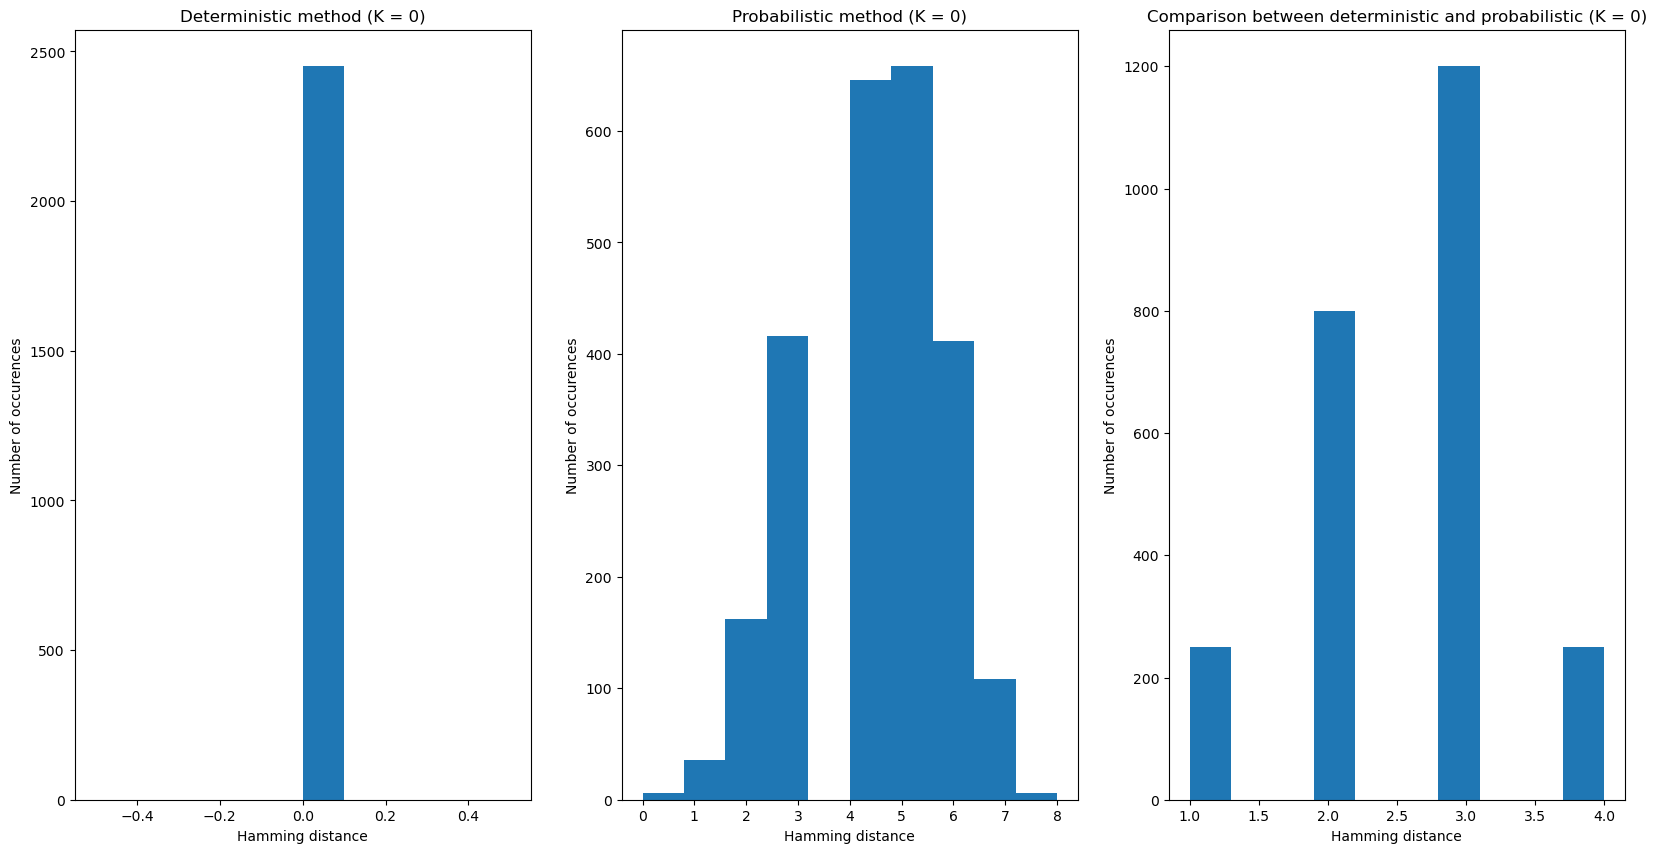

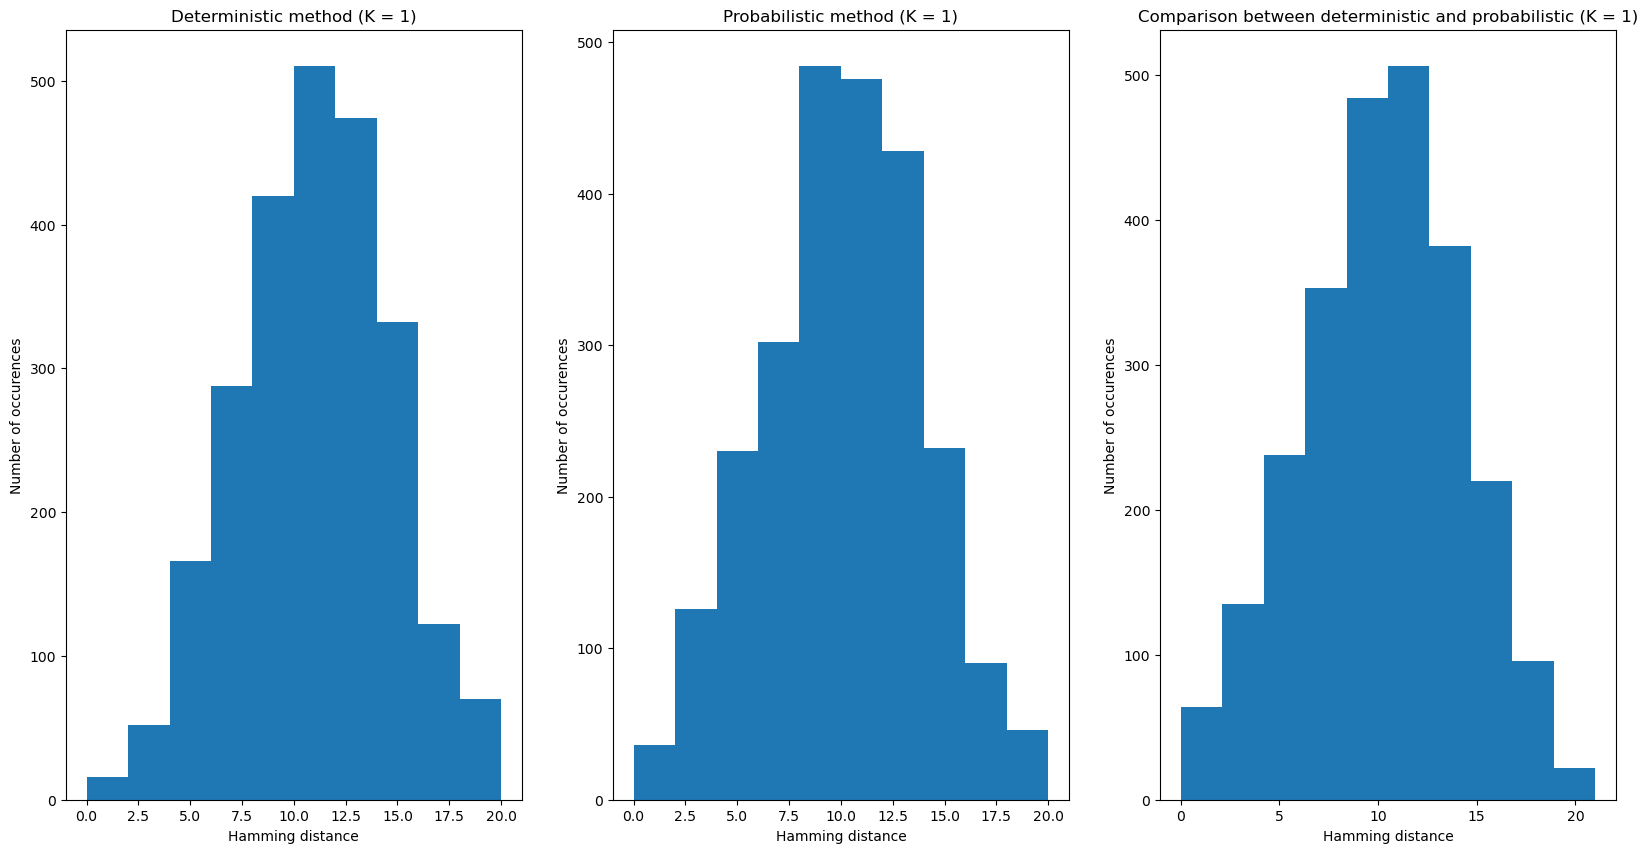

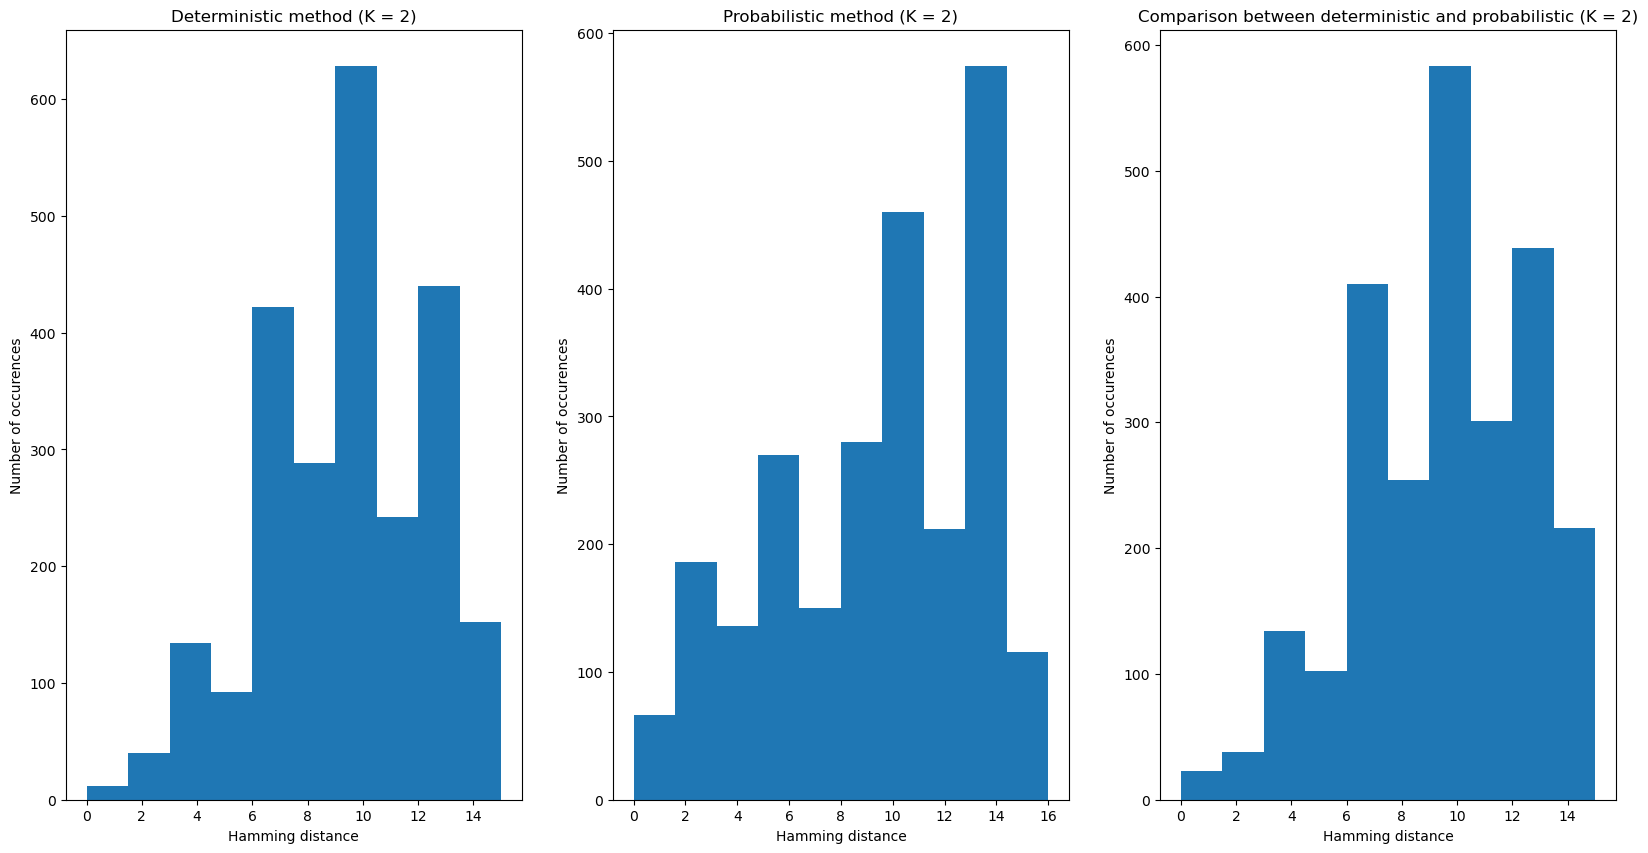

In [151]:
## TODO : Plot and analyze pairwise hamming distances for all methods and K values

for K in range(3):
    y_1 = np.array(deterministic_samples[K])[:, 0]
    y_2 = np.array(probabilistic_samples[K])[:, 0]
    assert len(y_1) == len(y_2)
    histogram_1 = []
    histogram_2 = []
    histogram_comparison = []
    for i in range(len(y_1)):
        for j in range(len(y_2)):
            if i != j:
                histogram_1.append(hamming_distance(y_1[i], y_1[j]))
                histogram_2.append(hamming_distance(y_2[i], y_2[j]))
            histogram_comparison.append(hamming_distance(y_1[i], y_2[j]))

    plt.figure(figsize=(20,10))
    plt.subplot(1, 3, 1)
    plt.title(f"Deterministic method (K = {K})")
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of occurences")
    plt.hist(histogram_1)
    plt.subplot(1, 3, 2)
    plt.title(f"Probabilistic method (K = {K})")
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of occurences")
    plt.hist(histogram_2)
    plt.subplot(1, 3, 3)
    plt.title(f"Comparison between deterministic and probabilistic (K = {K})")
    plt.xlabel("Hamming distance")
    plt.ylabel("Number of occurences")
    plt.hist(histogram_comparison)
    plt.show()

In [ ]:
## TODO : Describe and discuss the behaviour and the performance (in terms of the quality of the solutions) of each exploration method.

In [ ]:
## TODO : Answer the questions from TP 

1. What is the roughness of the landscape ?

    The roughness of the landscape is given by the fitness

2. What is the research space of the employed optimization methods ?

    The research space of the employed optimization methods is given by 

3. How are the two methods different ?

    The deterministic method can return a maximum that is not the maximum fitness whereas the probabilistic method can return a value that is not the maximum, but will never be blocked in a local maximum... 

4. What is the neighborhood of an element of the research space ?

    The neighborhood of an element of the research space is the set of all bit sequences that have only 1 bit that differs.

5. Is the solution of the optimization an element belonging to the research space or the fitness space ?

    The solution of the optimization give an element into fitness space